# CNLM-Langevin (fast-slow) — Interactive Demo

This notebook demonstrates the **CNLM-Langevin** solver on a single SAT and a single MaxSAT instance, exposing every internal quantity the algorithm produces. All computation flows through the public API of the `cnlm_langevin` package — no private hooks.

## The method (brief)

We replace each Boolean variable $x_i \in \{0,1\}$ by a continuous embedding $x_i = \sigma(z_i)$, $z_i \in \mathbb{R}$. For a CNF clause $C_j$ with literals encoded by signed row $\mathbf{L}_j \in \{-1,0,+1\}^n$,

$$\tilde s_j(z) \;=\; \sum_i L_{j,i}\,\sigma(z_i) \;+\; (|N_j|-1+\varepsilon),$$

where $|N_j|$ is the number of negative literals in $C_j$ and $\varepsilon\in(0,1)$. The clause is satisfied iff $\tilde s_j(z)>0$.

The lifted free energy is

$$\widetilde F_\lambda(z;c) \;=\; -\sum_j w_j \ln\!\bigl(1 + e^{c_j\,\tilde s_j(z)}\bigr) \;+\; \tfrac{\lambda}{2}\|z\|^2.$$

Two coupled SDEs evolve $(z,\rho)$ with $c=e^{\rho}$:

$$\boxed{\;\mathrm{d}z_t = -\nabla_z \widetilde F_\lambda(z_t;c_t)\,\mathrm{d}t + \sqrt{2/\beta_t}\,\mathrm{d}W^z_t\;}\quad\text{(fast)}$$
$$\boxed{\;\mathrm{d}\rho_t = -\eta\,\nabla_\rho \widetilde F_\lambda(z_t;e^{\rho_t})\,\mathrm{d}t + \sqrt{2\eta/\beta_c}\,\mathrm{d}W^\rho_t\;}\quad\text{(slow)}$$

with logarithmic cooling on $\beta_t$ and polynomial growth on $c_t$, in line with the cooling theorem.

Sixteen Langevin walkers are advanced in parallel (vectorised over chains), and the package exposes a `ProcessPoolExecutor` driver across instances when running on a folder of `.cnf` / `.wcnf` files.

## 1. Setup

In [1]:
import sys, os, json, time, textwrap, tempfile
from pathlib import Path

# ensure the package is importable when the notebook is run from examples/
ROOT = Path.cwd()
if (ROOT / "cnlm_langevin").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "cnlm_langevin").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown

import cnlm_langevin as cnlm
print("cnlm_langevin", cnlm.__version__)


cnlm_langevin 1.1.0


## 2. SAT demo — a small random 3-SAT instance

We build a satisfiable random 3-SAT in DIMACS form, then parse it through `parse_dimacs_cnf`.

In [ ]:
def random_3sat_dimacs(n_vars=20, n_clauses=85, seed=2):
    rng = np.random.default_rng(seed)
    lines = [f"p cnf {n_vars} {n_clauses}"]
    # plant a satisfying assignment
    plant = rng.integers(0, 2, size=n_vars).astype(bool)
    for _ in range(n_clauses):
        idx = rng.choice(n_vars, size=3, replace=False)
        lits = []
        sat = False
        for v in idx:
            sign = rng.integers(0, 2) * 2 - 1   # +/- 1
            lit = (int(v) + 1) * int(sign)
            lits.append(lit)
            # is this literal satisfied by plant?
            if (sign > 0 and plant[v]) or (sign < 0 and not plant[v]):
                sat = True
        if not sat:
            # flip one literal so that the clause is satisfied by `plant`
            v = idx[0]
            lits[0] = (int(v) + 1) if plant[v] else -(int(v) + 1)
        lines.append(" ".join(str(l) for l in lits) + " 0")
    return "\n".join(lines) + "\n"

cnf_text = random_3sat_dimacs()
tmp_cnf = Path(tempfile.gettempdir()) / "demo_uf20.cnf"
tmp_cnf.write_text(cnf_text)
print(tmp_cnf, " — first 6 lines:")
print("\n".join(cnf_text.splitlines()[:6]))


/tmp/demo_uf20.cnf  — first 6 lines:
p cnf 20 85
-20 11 6 0
-18 5 9 0
-8 1 7 0
-13 17 18 0
-5 -9 -12 0


In [3]:
parsed = cnlm.parse_dimacs_cnf(tmp_cnf)
sat_inst = cnlm.SATInstance.from_parsed(parsed, name=tmp_cnf.name)
print(sat_inst)
print("first 5 clauses:", sat_inst.clauses[:5])


SATInstance(n_vars=20, clauses=[[-20, 11, 6], [-18, 5, 9], [-8, 1, 7], [-13, 17, 18], [-5, -9, -12], [18, -4, 9], [11, 10, 13], [5, -9, 17], [9, 2, -16], [-10, 2, -14], [12, -10, 14], [8, -19, 14], [-20, -8, -15], [-12, 4, 15], [-7, 6, 2], [12, -10, 9], [-16, 4, -12], [-20, 2, -14], [-18, -9, -6], [-9, 1, -13], [-8, -10, -19], [14, 20, -8], [-20, 3, -16], [1, -12, 5], [14, 2, 6], [-2, -17, 13], [19, -18, -20], [-14, -17, -19], [-2, 1, 12], [16, -20, -19], [8, 15, -19], [13, 7, -17], [-12, 11, -9], [-18, -1, -17], [-4, -9, 11], [18, 13, -3], [13, 14, 7], [12, 10, -8], [19, -16, 3], [14, 16, -3], [12, 4, 5], [19, 1, 2], [10, -2, 12], [-3, 6, 15], [-16, 19, 8], [-18, -20, -10], [11, 2, 4], [4, 10, -6], [-18, -11, -9], [9, 4, -19], [-2, 5, 19], [6, -2, 16], [-6, -4, 3], [15, -19, -18], [20, -15, -12], [-4, -7, -19], [20, -10, -1], [10, 19, 11], [-17, -5, 7], [17, 19, -12], [17, -4, -12], [-11, -13, 6], [-2, -19, -10], [-12, -15, -18], [13, -18, -15], [1, -9, 7], [-7, -11, 10], [-20, -8, 5]

## 3. Configure and run the solver

We turn on the **slow SDE on $\rho$** so the demo exercises the full fast-slow coupling, and we record the per-chain assignment trajectory so we can visualise it.

In [4]:
cfg_sat = cnlm.SolverConfig(
    n_steps=1000,
    dt=0.05,
    n_chains=16,
    seed=11,
    eps=0.5,
    lam=1e-3,
    z_init_scale=0.5,
    beta_init=1.0,
    beta_final=80.0,
    beta_schedule="log",
    c_init=1.0,
    c_final=60.0,
    c_schedule="lin",
    use_slow_sde=True,
    eta=0.05,
    beta_c=50.0,
    early_stop_when_sat=True,
    restart_on_stuck=True,
    stuck_patience=200,
    record_history_every=1,
    record_assignment_every=10,   # store soft-assignment x for trajectory plot
)

solver = cnlm.CNLMLangevinSolver(sat_inst, cfg_sat)
sat_res = solver.solve()
print(f"is_SAT       = {sat_res.is_SAT}")
print(f"n_satisfied  = {sat_res.n_satisfied}/{sat_res.n_clauses}")
print(f"sat_score    = {sat_res.sat_score:.4f}")
print(f"runtime      = {sat_res.runtime_s*1000:.1f} ms")
print(f"converged at step {sat_res.converged_step} (best chain = {sat_res.best_chain})")


is_SAT       = False
n_satisfied  = 83/85
sat_score    = 0.9765
runtime      = 325.1 ms
converged at step 9 (best chain = 1)


### Pretty-printed summary

In [5]:
def pretty_summary(res, instance, title):
    rows = [
        ("problem type", res.problem_type),
        ("n_vars / n_clauses", f"{instance.n_vars} / {instance.n_clauses}"),
        ("is_SAT (full / hard sat)", str(res.is_SAT)),
        ("n_satisfied / n_clauses", f"{res.n_satisfied} / {res.n_clauses}"),
        ("SAT score", f"{res.sat_score:.4f}"),
    ]
    if res.problem_type == "MaxSAT":
        rows += [
            ("hard sat", f"{res.n_hard_sat} / {res.n_hard_total}"),
            ("soft sat", f"{res.n_soft_sat} / {res.n_soft_total}"),
            ("soft weight satisfied", f"{res.soft_weight_satisfied:.3f}"),
            ("MaxSAT cost (soft weight unsat)", f"{res.cost:.3f}"),
        ]
    rows += [
        ("n chains", str(res.n_chains)),
        ("n steps", str(res.n_steps)),
        ("converged step", str(res.converged_step)),
        ("runtime", f"{res.runtime_s*1000:.1f} ms"),
    ]
    body = "".join(
        f"<tr><td style='padding:2px 14px;color:#555'>{k}</td>"
        f"<td style='padding:2px 14px;font-family:monospace'><b>{v}</b></td></tr>"
        for k, v in rows
    )
    html = (
        f"<div style='font-family:sans-serif'>"
        f"<h4 style='margin-bottom:4px'>{title}</h4>"
        f"<table style='border-collapse:collapse'>{body}</table></div>"
    )
    display(HTML(html))

pretty_summary(sat_res, sat_inst, "SAT result — random 3-SAT n=20, m=85")


problem type,SAT
n_vars / n_clauses,20 / 85
is_SAT (full / hard sat),False
n_satisfied / n_clauses,83 / 85
SAT score,0.9765
n chains,16
n steps,1000
converged step,9
runtime,325.1 ms


### Verify the assignment by hand against every clause

In [6]:
x = sat_res.assignment.astype(bool)
sat_mask = sat_res.sat_mask if sat_res.sat_mask is not None else \
           np.array([
               any(((lit > 0 and x[abs(lit)-1]) or (lit < 0 and not x[abs(lit)-1]))
                   for lit in C)
               for C in sat_inst.clauses
           ])
print(f"independent verification: {int(sat_mask.sum())}/{len(sat_mask)} clauses satisfied")
print("first 12 clauses with verdict:")
for j, C in enumerate(sat_inst.clauses[:12]):
    print(f"  C{j:2d} = {str(C):<22s}  ->  {'SAT' if sat_mask[j] else 'UNSAT'}")


independent verification: 83/85 clauses satisfied
first 12 clauses with verdict:
  C 0 = [-20, 11, 6]            ->  SAT
  C 1 = [-18, 5, 9]             ->  SAT
  C 2 = [-8, 1, 7]              ->  SAT
  C 3 = [-13, 17, 18]           ->  SAT
  C 4 = [-5, -9, -12]           ->  SAT
  C 5 = [18, -4, 9]             ->  SAT
  C 6 = [11, 10, 13]            ->  SAT
  C 7 = [5, -9, 17]             ->  SAT
  C 8 = [9, 2, -16]             ->  SAT
  C 9 = [-10, 2, -14]           ->  SAT
  C10 = [12, -10, 14]           ->  SAT
  C11 = [8, -19, 14]            ->  SAT


## 4. Visualisations on the SAT instance

Every plot below is produced by a function of the public `cnlm_langevin.viz` API and is reused by the per-instance directory writer in `solve_folder` / `run_SAT.py`.

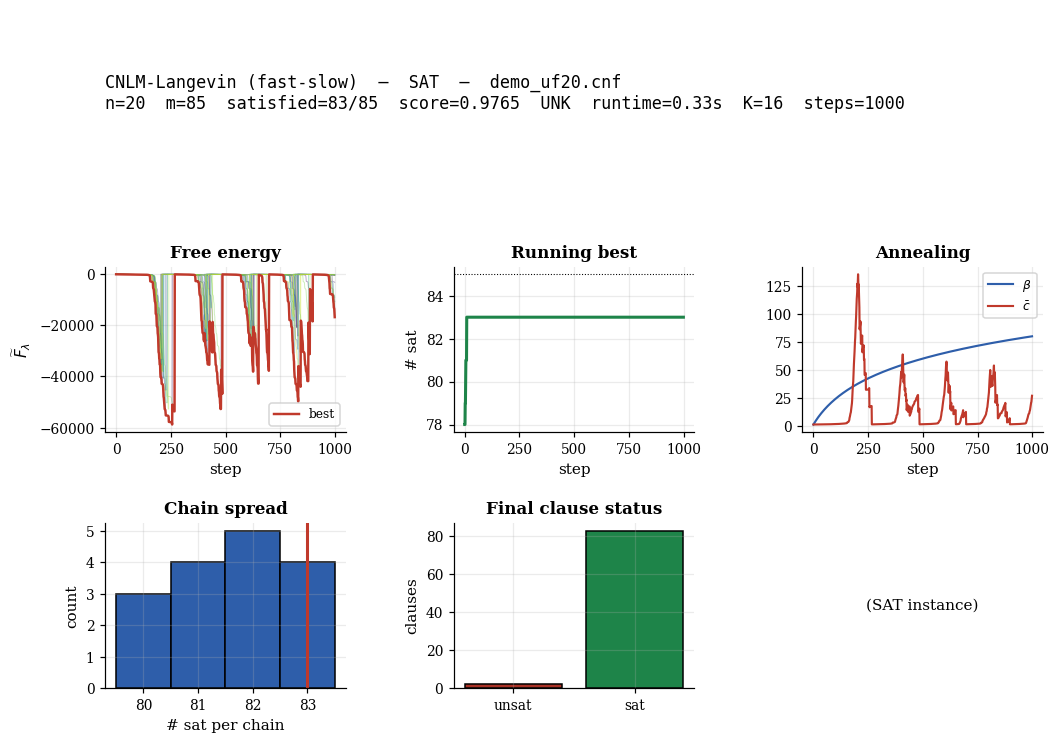

In [7]:
fig = cnlm.plot_solution_summary(sat_res, sat_inst); plt.show()

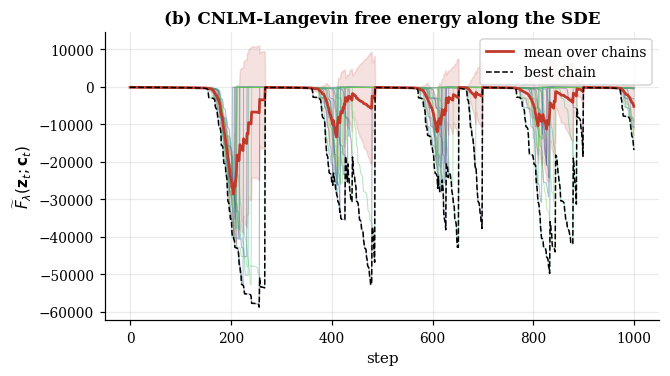

In [8]:
fig = cnlm.plot_energy_curve(sat_res); plt.show()

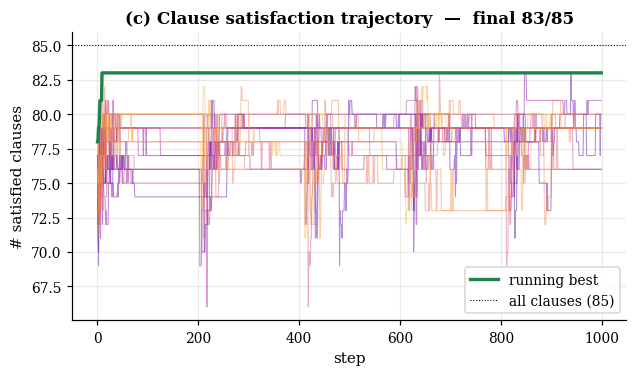

In [9]:
fig = cnlm.plot_clause_satisfaction(sat_res); plt.show()

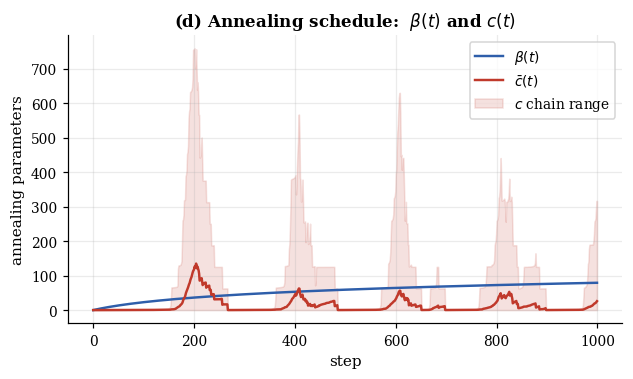

In [10]:
fig = cnlm.plot_confidence_evolution(sat_res); plt.show()

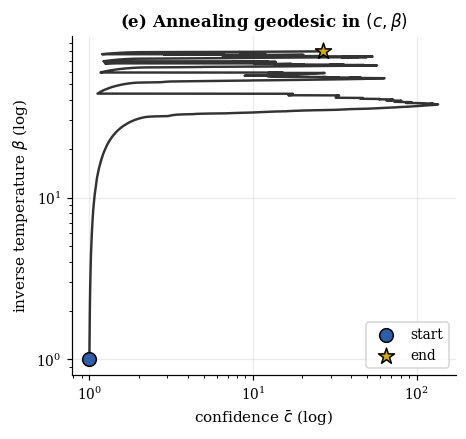

In [11]:
fig = cnlm.plot_schedule(sat_res); plt.show()

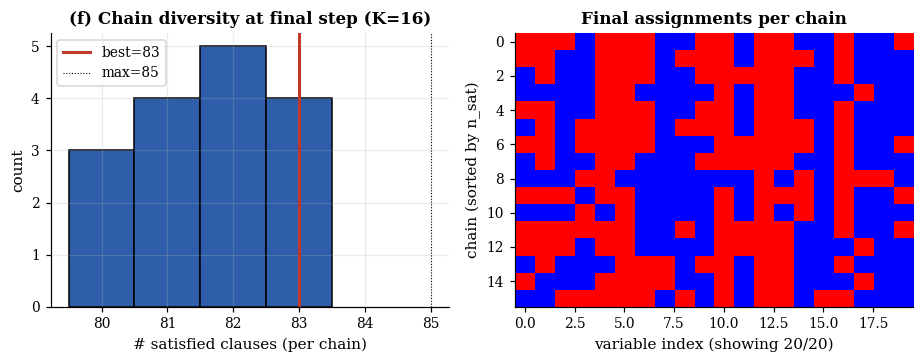

In [12]:
fig = cnlm.plot_chain_diversity(sat_res); plt.show()

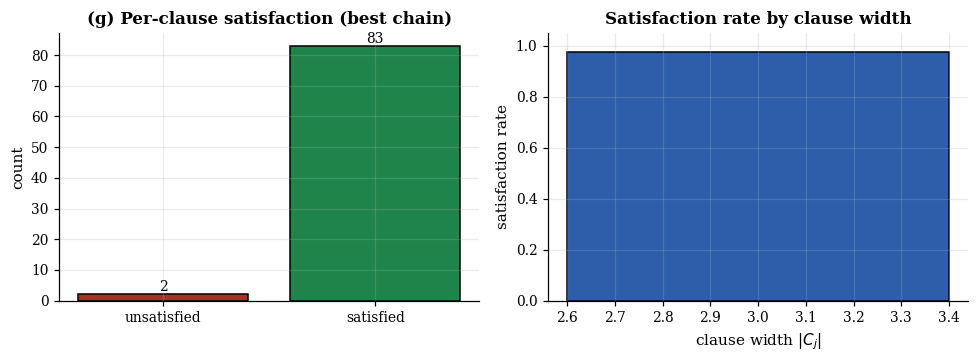

In [13]:
fig = cnlm.plot_score_distribution(sat_res, sat_inst); plt.show()

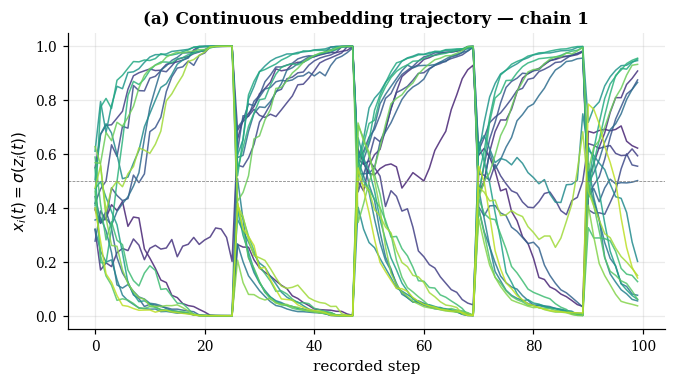

In [14]:
# soft-assignment trajectory of the best chain across the embedding x = σ(z)
fig = cnlm.plot_assignment_trajectory(sat_res, chain=sat_res.best_chain, max_vars=20); plt.show()


## 5. MaxSAT demo — a small weighted partial MaxSAT (new format)

We synthesize a weighted partial MaxSAT (`.wcnf`, MSE-2022 'h' format) by combining a satisfiable hard core with conflicting soft clauses, then exercise the same solver.

In [15]:
def small_wcnf(seed=3):
    # 6 variables, 4 hard clauses (consistent), 6 soft clauses (some conflicting).
    rng = np.random.default_rng(seed)
    n = 6
    hard = [
        [1, 2, 3],
        [-1, -4, 5],
        [4, -5, 6],
        [-2, 3, -6],
    ]
    soft = [
        ([1],            3.0),
        ([-1],           1.0),    # conflicts with the previous one
        ([2, -3],        2.0),
        ([-2, 3, -4],    2.5),
        ([4, 5],         1.5),
        ([-5, 6],        1.0),
    ]
    n_clauses = len(hard) + len(soft)
    lines = [f"p wcnf {n} {n_clauses}"]
    # MSE-2022 'h' style: hard prefix is the literal 'h'
    for C in hard:
        lines.append("h " + " ".join(str(x) for x in C) + " 0")
    for C, w in soft:
        lines.append(f"{w:g} " + " ".join(str(x) for x in C) + " 0")
    return "\n".join(lines) + "\n"

wcnf_text = small_wcnf()
tmp_wcnf = Path(tempfile.gettempdir()) / "demo.wcnf"
tmp_wcnf.write_text(wcnf_text)
print(wcnf_text)


p wcnf 6 10
h 1 2 3 0
h -1 -4 5 0
h 4 -5 6 0
h -2 3 -6 0
3 1 0
1 -1 0
2 2 -3 0
2.5 -2 3 -4 0
1.5 4 5 0
1 -5 6 0



In [16]:
parsed_w = cnlm.parse_dimacs_wcnf(tmp_wcnf)
ms_inst = cnlm.MaxSATInstance.from_parsed(parsed_w, name=tmp_wcnf.name)
print(ms_inst)
print("hard mask:", ms_inst.is_hard)
print("weights  :", ms_inst.weights)


MaxSATInstance(n_vars=6, clauses=[[1, 2, 3], [-1, -4, 5], [4, -5, 6], [-2, 3, -6], [1], [-1], [2, -3], [-2, 3, -4], [4, 5], [-5, 6]], weights=array([inf, inf, inf, inf, 3. , 1. , 2. , 2.5, 1.5, 1. ]), is_hard=array([ True,  True,  True,  True, False, False, False, False, False,
       False]), top=inf, name='demo.wcnf', new_format=True)
hard mask: [ True  True  True  True False False False False False False]
weights  : [inf inf inf inf 3.  1.  2.  2.5 1.5 1. ]


In [17]:
cfg_ms = cnlm.SolverConfig(
    n_steps=1500,
    dt=0.05,
    n_chains=16,
    seed=7,
    use_slow_sde=True,
    early_stop_when_sat=True,
    record_assignment_every=10,
    hard_scale=1e3,
)
ms_res = cnlm.CNLMLangevinSolver(ms_inst, cfg_ms).solve()
pretty_summary(ms_res, ms_inst, "MaxSAT result — n=6, m=10 (4 hard, 6 soft)")


problem type,MaxSAT
n_vars / n_clauses,6 / 10
is_SAT (full / hard sat),True
n_satisfied / n_clauses,9 / 10
SAT score,0.9000
hard sat,4 / 4
soft sat,5 / 6
soft weight satisfied,10.000
MaxSAT cost (soft weight unsat),1.000
n chains,16
n steps,1500


### Brute-force optimum (sanity-check, only feasible for tiny instances)

In [18]:
def brute_optimum(inst):
    n = inst.n_vars
    best_cost = np.inf
    best_x = None
    best_hard_ok = False
    for k in range(1 << n):
        x = np.array([(k >> i) & 1 for i in range(n)], dtype=bool)
        hard_ok = True
        cost = 0.0
        for j, C in enumerate(inst.clauses):
            sat = any(((l > 0 and x[abs(l)-1]) or (l < 0 and not x[abs(l)-1])) for l in C)
            if inst.is_hard[j] and not sat:
                hard_ok = False
                break
            if (not inst.is_hard[j]) and not sat:
                cost += float(inst.weights[j])
        if not hard_ok:
            continue
        if (not best_hard_ok) or cost < best_cost:
            best_hard_ok = True
            best_cost = cost
            best_x = x
    return best_x, best_cost

bx, bc = brute_optimum(ms_inst)
display(HTML(
    f"<div style='font-family:sans-serif'>"
    f"<b>brute-force optimum</b>: cost = <code>{bc:.3f}</code>, assignment = "
    f"<code>{bx.astype(int).tolist()}</code><br>"
    f"<b>CNLM-Langevin found</b>:  cost = <code>{ms_res.cost:.3f}</code>, assignment = "
    f"<code>{ms_res.assignment.astype(int).tolist()}</code><br>"
    f"<b>gap</b>: <code>{ms_res.cost - bc:.3f}</code></div>"
))


### MaxSAT-specific visualisations

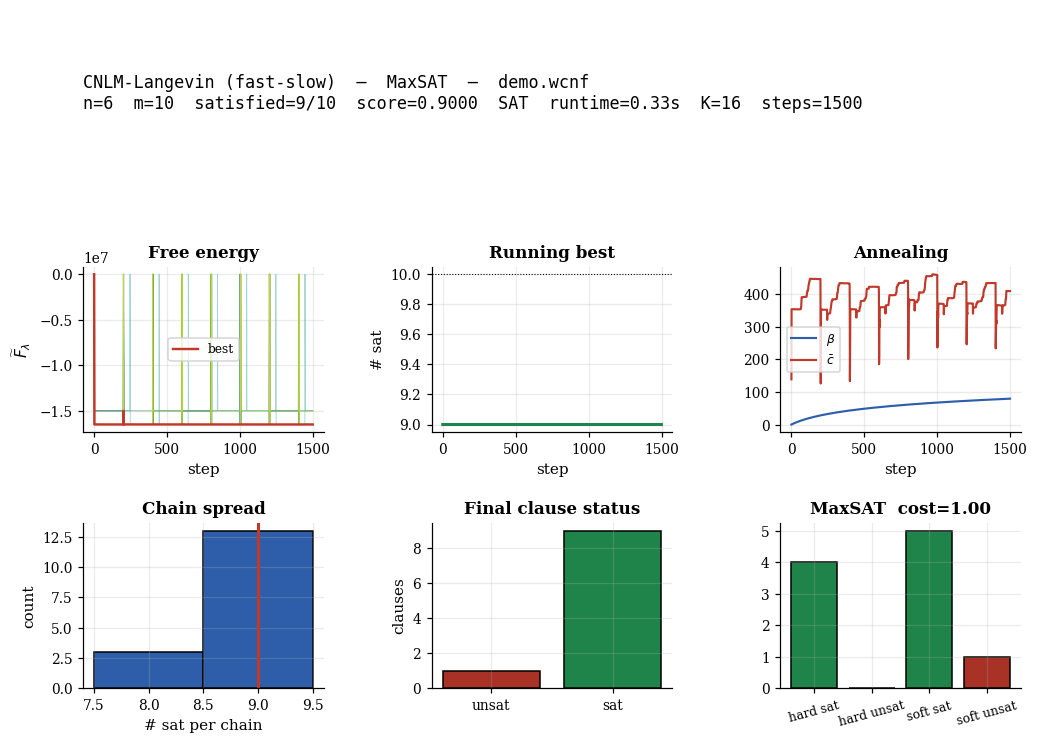

In [19]:
fig = cnlm.plot_solution_summary(ms_res, ms_inst); plt.show()

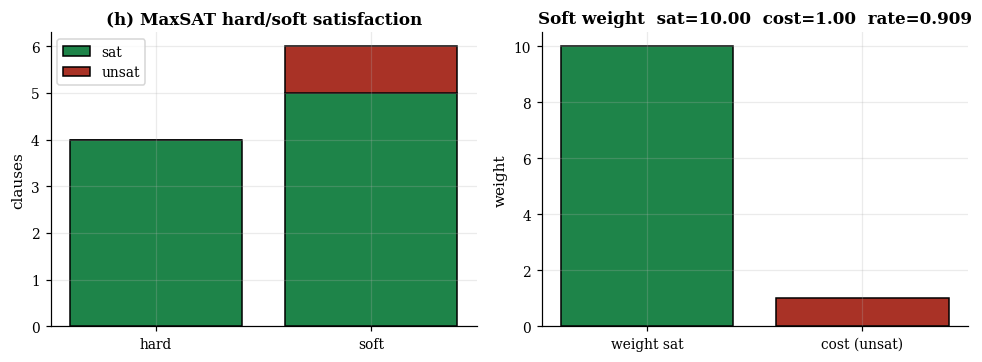

In [20]:
fig = cnlm.plot_maxsat_breakdown(ms_res, ms_inst); plt.show()

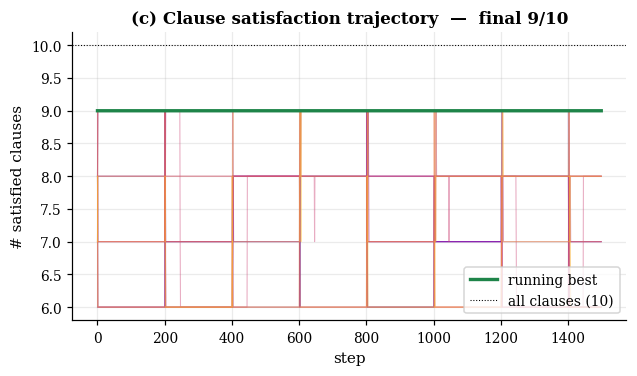

In [21]:
fig = cnlm.plot_clause_satisfaction(ms_res); plt.show()

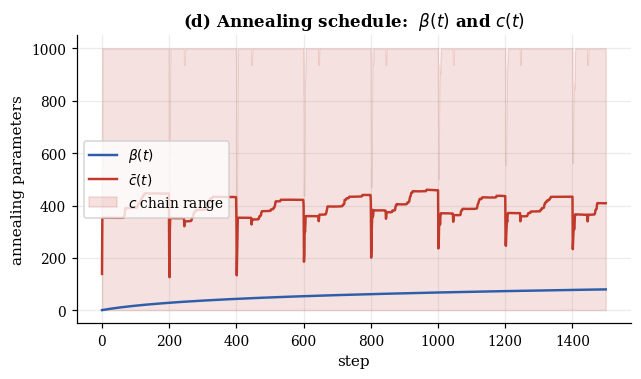

In [22]:
fig = cnlm.plot_confidence_evolution(ms_res); plt.show()

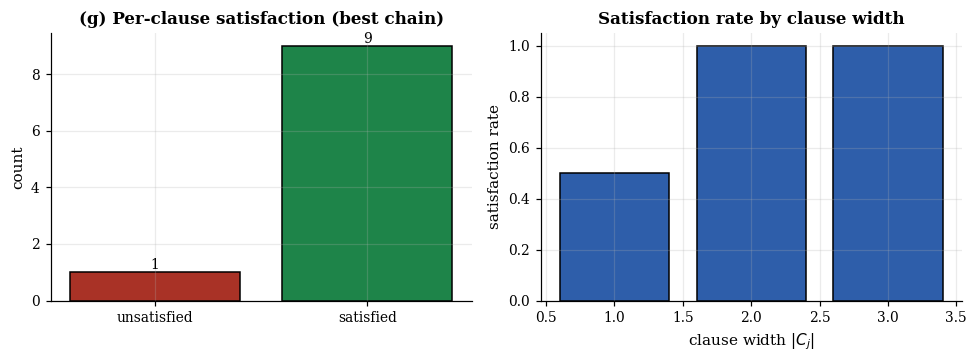

In [23]:
fig = cnlm.plot_score_distribution(ms_res, ms_inst); plt.show()

## 6. Folder driver — multi-process across instances

Both `run_SAT.py` and `run_MaxSAT.py` are thin wrappers around `cnlm.solve_folder`, which uses a `ProcessPoolExecutor` to dispatch one instance per worker. Each instance produces its own folder with the full `summary.json`, `result_full.npz` (compressed histories + assignments) and all the plots above.

In [24]:
# build a tiny folder of CNFs and solve them in parallel
demo_folder = Path(tempfile.mkdtemp(prefix="cnlm_demo_"))
for k in range(3):
    (demo_folder / f"rand_{k}.cnf").write_text(random_3sat_dimacs(seed=10 + k))

out_dir = demo_folder / "_results"
results = cnlm.solve_folder(
    demo_folder,
    out_dir,
    problem_type="SAT",
    n_workers=3,
    config=cnlm.SolverConfig(n_steps=600, n_chains=12, seed=0),
    save_plots=False,    # keep notebook tidy
    progress=True,
)
print(f"\n=> {len(results)} instance(s) solved, results under {out_dir}")


[1/3] rand_0.cnf: UNK 84/85 (0.988) in 0.43s


[2/3] rand_1.cnf: UNK 83/85 (0.976) in 0.42s


[3/3] rand_2.cnf: UNK 83/85 (0.976) in 0.42s



CNLM-Langevin (fast-slow) — folder summary
  files in       : /tmp/cnlm_demo_jdy1r9un
  files out      : /tmp/cnlm_demo_jdy1r9un/_results
  problem type   : SAT
  files solved   : 3/3
  fully SAT/HARD : 0 (0.0%)
  sat score mean : 0.9804  (median 0.9765, min 0.9765)
  runtime totals : sum=1.27s  mean=0.42s  workers=3

=> 2 instance(s) solved, results under /tmp/cnlm_demo_jdy1r9un/_results


In [25]:
print("top-level files:", sorted(p.name for p in out_dir.iterdir() if p.is_file()))
print("per-instance dirs:", sorted(p.name for p in out_dir.iterdir() if p.is_dir()))
print()
print("summary.csv (head):")
print(textwrap.indent((out_dir / 'summary.csv').read_text()[:600], '  '))


top-level files: ['all_results.json', 'summary.csv']
per-instance dirs: ['rand_0', 'rand_1', 'rand_2']

summary.csv (head):
  instance_name,problem_type,n_vars,n_clauses,is_SAT,n_satisfied,sat_score,runtime_s,n_steps,n_chains,best_chain,converged_step
  rand_0.cnf,SAT,20,85,False,84,0.9882352941176471,0.4322302570000147,600,12,0,22
  rand_1.cnf,SAT,20,85,False,83,0.9764705882352941,0.41745686299998397,600,12,0,0
  rand_2.cnf,SAT,20,85,False,83,0.9764705882352941,0.415928493000024,600,12,0,16



## 7. Paper-style figures (v1.1)

Five additional figures inspired by the paper:

* `plot_clause_veritron_heatmap` — per-clause $\nu_j(t) = \sigma(c_t\,\tilde s_j(z_t))$ heatmap along a chain.
* `plot_loss_landscape_sweep` — sweep $c$ to show the lifted free energy morphing convex → V-basin.
* `plot_sde_trajectory_2d` — hexbin density of the chain ensemble in $z$-space across annealing epochs.
* `plot_convergence_to_corners` — $x_i(t)$ on the left, $\|x(t)-x^*\|_2$ to every Boolean corner on the right.
* `analyze_gradient_snr` + `plot_gradient_snr` — pre-solve diagnostic of $|\mathbb{E}[\partial_c F_j]|/\sigma$ over uniform random $x$.

### 7.1 Per-clause Veritron heatmap

long-trajectory solve: SAT=False 82/85, history_x.shape=(200, 12, 20)


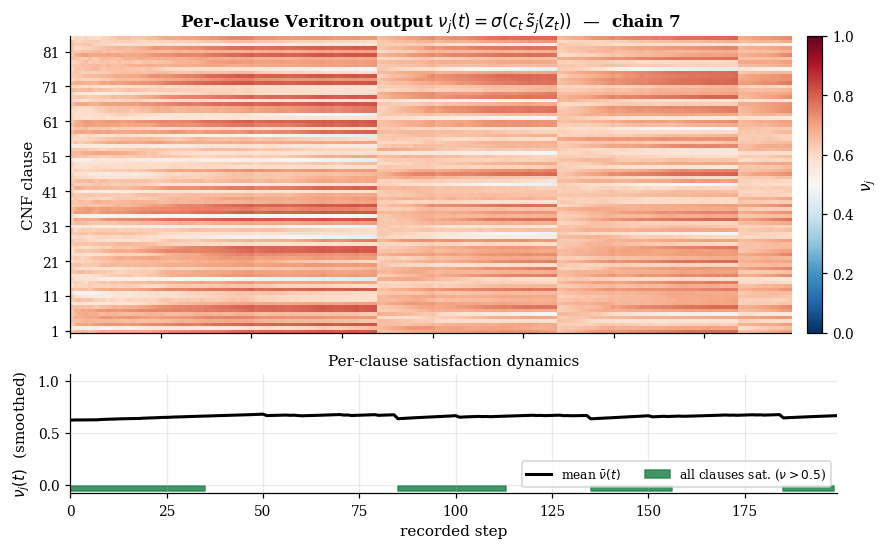

In [26]:
# Re-solve disabling early-stop so we get a long, recorded trajectory
cfg_long = cnlm.SolverConfig(
    n_steps=800, n_chains=12, seed=11,
    use_slow_sde=True,
    record_assignment_every=4,
    early_stop_when_sat=False,    # keep running so the trajectory is rich
    beta_init=0.5, beta_final=80.0,
    c_init=0.5, c_final=40.0,
)
sat_res_long = cnlm.CNLMLangevinSolver(sat_inst, cfg_long).solve()
print(f"long-trajectory solve: SAT={sat_res_long.is_SAT} "
      f"{sat_res_long.n_satisfied}/{sat_res_long.n_clauses}, "
      f"history_x.shape={sat_res_long.history_x.shape}")

fig = cnlm.plot_clause_veritron_heatmap(sat_res_long, sat_inst); plt.show()


### 7.2 Loss-landscape sweep — convex → V-basin

We use a tiny 2-variable instance to get a clean canonical landscape, then sweep `c`.

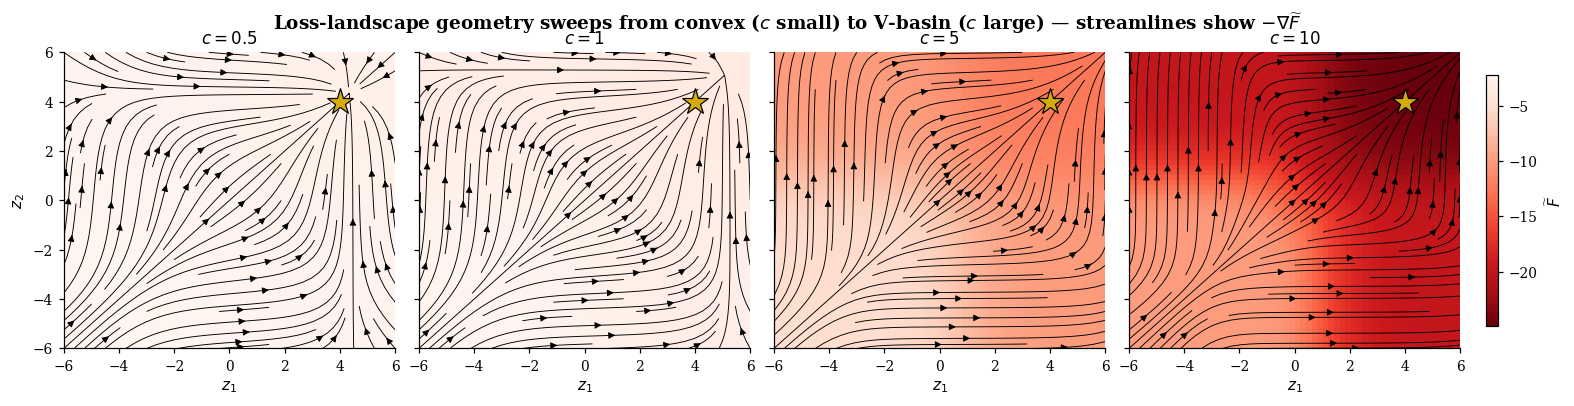

In [27]:
# Canonical 2-var instance: x1=1, x2=1 is the unique satisfying corner
clauses_2v = [[1, 2], [-1, 2], [1, -2]]
inst2 = cnlm.SATInstance.from_clauses(2, clauses_2v, name="2var_demo")
fig = cnlm.plot_loss_landscape_sweep(
    inst2, c_values=(0.5, 1.0, 5.0, 10.0),
    grid=60, star=(4.0, 4.0),
); plt.show()


### 7.3 SDE trajectory hexbin across annealing epochs

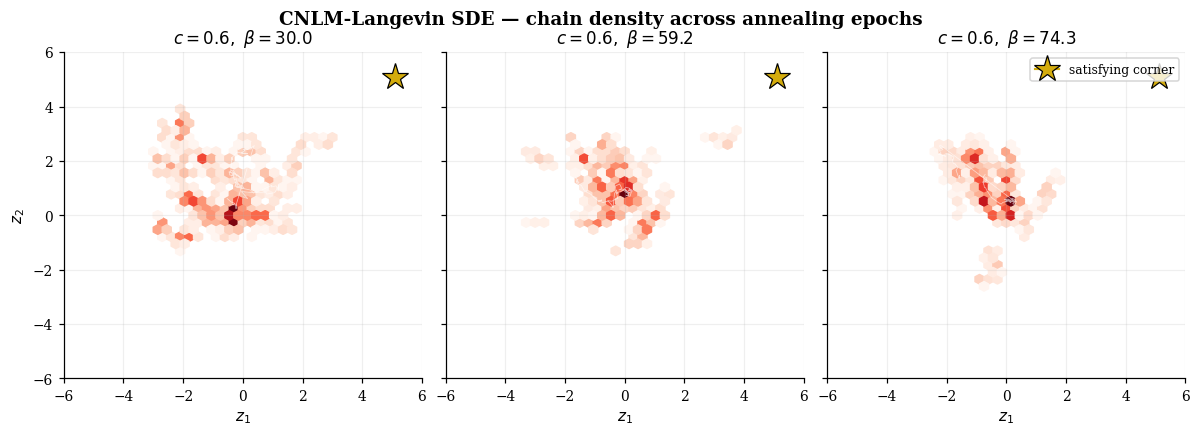

In [28]:
fig = cnlm.plot_sde_trajectory_2d(
    sat_res_long, sat_inst, project=(0, 1), n_panels=3,
); plt.show()


### 7.4 Convergence to Boolean corners

For $n \leq 12$ we enumerate all $2^n$ corners of the unit cube; SAT corners appear as coloured solid lines, UNSAT corners as light grey traces, with $c(t)$ overlaid.

6-var solve: 18/18


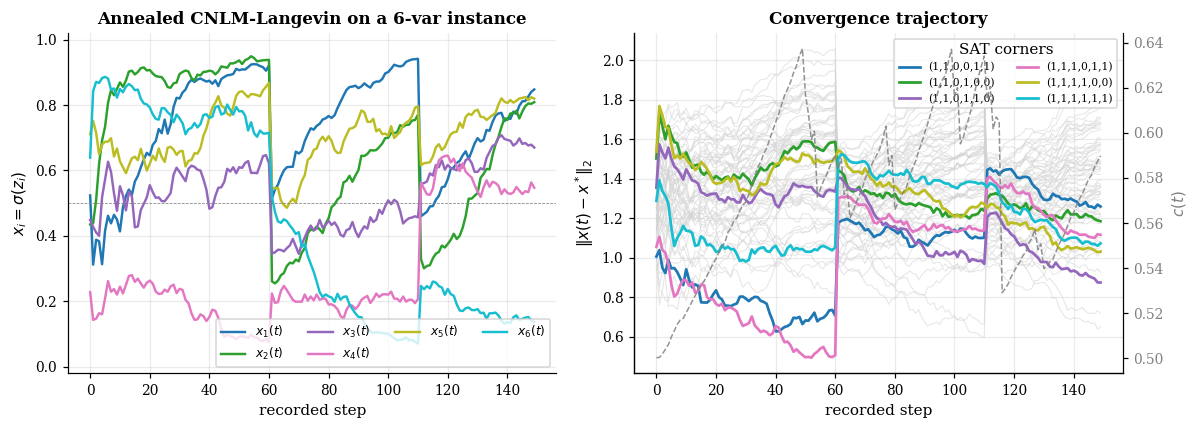

In [29]:
# build a small (n=6) SAT for clean enumeration
small_cnf_text = random_3sat_dimacs(n_vars=6, n_clauses=18, seed=4)
tmp_small = Path(tempfile.gettempdir()) / "tiny6.cnf"
tmp_small.write_text(small_cnf_text)
parsed_small = cnlm.parse_dimacs_cnf(tmp_small)
inst_small = cnlm.SATInstance.from_parsed(parsed_small, name="tiny6")

cfg_small = cnlm.SolverConfig(
    n_steps=600, n_chains=12, seed=2, use_slow_sde=True,
    record_assignment_every=4, early_stop_when_sat=False,
    beta_init=0.5, beta_final=80.0, c_init=0.5, c_final=40.0,
)
res_small = cnlm.CNLMLangevinSolver(inst_small, cfg_small).solve()
print(f"6-var solve: {res_small.n_satisfied}/{res_small.n_clauses}")

fig = cnlm.plot_convergence_to_corners(res_small, inst_small); plt.show()


### 7.5 Gradient SNR — pre-solve confidence diagnostic

Computes $\mathrm{SNR}_j(c) = |\mathbb{E}_x[\partial_c F_j]|\,/\,\sigma_x[\partial_c F_j]$ over uniform-random $x \in (0,1)^n$, sweeping $c$ on a log-grid. Helps choose a c-schedule.

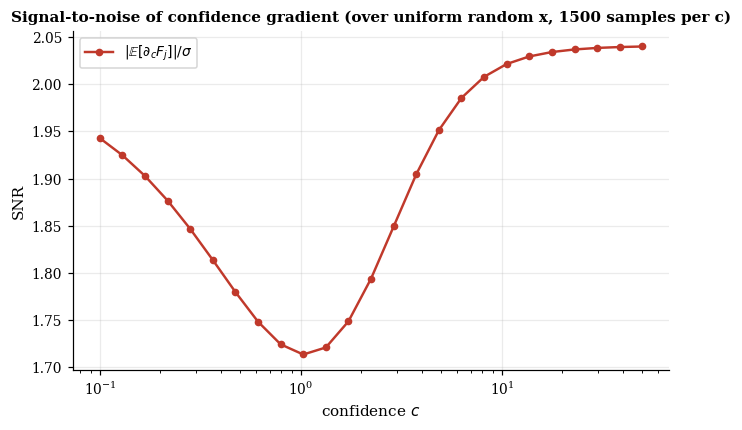

peak SNR: 2.040 at c=50.000


In [30]:
snr_data = cnlm.analyze_gradient_snr(sat_inst, n_samples=1500, seed=0)
fig = cnlm.plot_gradient_snr(snr_data); plt.show()
print(f"peak SNR: {snr_data['snr'].max():.3f} at c={snr_data['c_grid'][snr_data['snr'].argmax()]:.3f}")


## 8. Where to go from here

* `python run_SAT.py /path/to/folder_of_cnfs --workers 8 --steps 3000 --chains 32 --slow-sde`
* `python run_MaxSAT.py /path/to/folder_of_wcnfs --workers 8 --slow-sde`

Each instance directory will contain `summary.json`, `solution.txt`, `instance_meta.json`, `result_full.npz` (compressed histories + sat-mask + chain ensemble) and a battery of PDF plots (now including the four trajectory-dependent paper-style plots if `record_assignment_every>0`).
